# SAMI · Notebook 2 — Demand, behaviour & experience

**Mandate (Acts 2–3, quantitative).** What are people asking the bot, how does that
demand move across cities and weeks, how far does engagement carry, and how satisfied
are the few who tell us? Every figure carries an assertion-evidence title, its metric,
its n, and the observation window; every number traces to the P10 reconciliation table
reproduced at the top and bottom of this notebook. Modules compute, this notebook
consumes — no analytical logic lives in a cell.

> **Grain note.** Messages inherit the timestamp of their response record (there is no
> per-message timestamp). All weekly and daily trends are therefore at
> **record-arrival granularity**, not true per-message time.

In [1]:
import sys, pathlib
# Locate src/ by walking up from the working directory, so `sami` imports
# whether the kernel starts in notebooks/ (JupyterLab) or at the repo root
# (VS Code) — a bare "../src" only works in the first case.
_cwd = pathlib.Path.cwd()
_src = next((p / "src" for p in (_cwd, *_cwd.parents) if (p / "src" / "sami").is_dir()), None)
if _src is None:
    raise RuntimeError(f"Could not find src/sami/ above {_cwd}. "
                       "Run this notebook from inside the repository.")
sys.path.insert(0, str(_src))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sami import load_sami, stats, metrics, taxonomy, theme, canon, cohort

CAT_ORDER = taxonomy.OFFICIAL_CATEGORIES + ["unclassified"]
CAT_COLOR = dict(zip(CAT_ORDER, theme.bar_colors(len(CAT_ORDER))))
CAT_EN = {  # EN display for category labels (chart text only)
    "legal_documentation": "Legal & documentation",
    "humanitarian_assistance": "Humanitarian assistance",
    "protection": "Protection",
    "employment": "Employment",
    "organization_search": "Finding organizations",
    "journey_information": "Journey information",
    "services": "Services",
    "unclassified": "Unclassified",
}
SD = load_sami()
WINDOW = f"{SD.run_meta['ts_min'][:10]} → {SD.run_meta['ts_max'][:10]}"


In [2]:
print("Source:", SD.run_meta["responses_file"], "|", SD.run_meta["responses_rows"], "rows |", WINDOW)
recon_top = SD.reconciliation.copy()
recon_top


Source: Users_Group_Title_2807.xlsx | 1460 rows | 2026-03-25 → 2026-07-28


,metric,value
0,users,1392
1,records,1459
2,messages,4663
3,users_with_text,1198
4,meal_responses,115
5,meal_response_rate_pct,8.3
6,legal_documentation_pct,46.5
7,repeat_askers_pct,10.6
8,negative_tone_pct,pending


## 1 · Demand mix

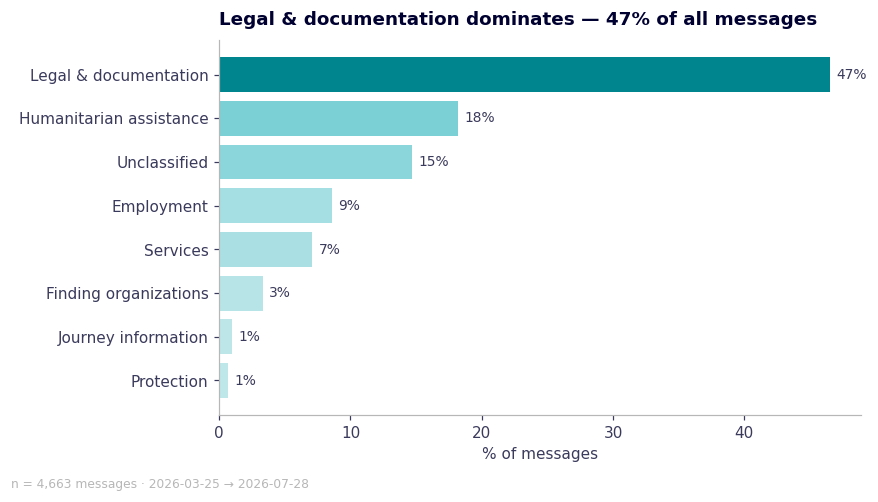

In [3]:
share = metrics.category_share(SD.messages).rename(index=CAT_EN)
vals = share.values * 100
fig, ax = plt.subplots(figsize=(8, 4.4))
# Sequential teal gradient by magnitude — darkest = largest share.
cmap = theme.blue_cmap(); norm = plt.Normalize(vals.min(), vals.max())
colors = [cmap(0.30 + 0.60 * norm(v)) for v in vals]
ax.barh(share.index[::-1], vals[::-1], color=colors[::-1])
for y, v in enumerate(vals[::-1]):
    ax.text(v + 0.5, y, f"{v:.0f}%", va="center", fontsize=9, color=theme.INK2)
ax.set_xlabel("% of messages"); ax.set_ylabel("")
ax.set_title(f"Legal & documentation dominates — {share.iloc[0]*100:.0f}% of all messages")
fig.text(0.01, -0.02, f"n = {len(SD.messages):,} messages · {WINDOW}", fontsize=8, color=theme.MUTED)
plt.tight_layout(); plt.show()


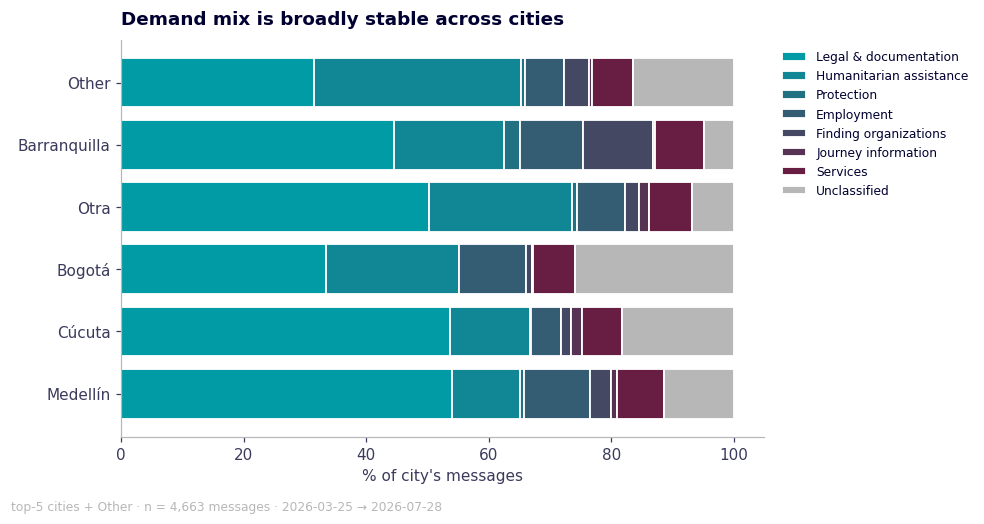

In [4]:
from matplotlib.colors import LinearSegmentedColormap
mix = metrics.city_category_mix(SD.messages, top_cities=5)
mix_en = mix.rename(columns=CAT_EN)
# One teal→wine ramp spanning the seven official categories (legal = teal end,
# humanitarian = wine end); 'unclassified' stays neutral grey, outside the ramp.
official = [c for c in CAT_ORDER if c != "unclassified"]
ramp = LinearSegmentedColormap.from_list("mix", [theme.PRIMARY, theme.ACCENT])
GRAD = {c: ramp(i / (len(official) - 1)) for i, c in enumerate(official)}
GRAD["unclassified"] = theme.MUTED
fig, ax = plt.subplots(figsize=(9, 4.6))
left = np.zeros(len(mix_en))
for cat in [c for c in CAT_ORDER if CAT_EN[c] in mix_en.columns]:
    vals = mix_en[CAT_EN[cat]].values * 100
    ax.barh(mix_en.index, vals, left=left, color=GRAD[cat], label=CAT_EN[cat],
            edgecolor=theme.SURFACE, linewidth=1.2)  # 2px surface gap between segments
    left += vals
ax.set_xlabel("% of city's messages"); ax.set_ylabel("")
ax.set_title("Demand mix is broadly stable across cities")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8, frameon=False)
fig.text(0.01, -0.02, f"top-5 cities + Other · n = {len(SD.messages):,} messages · {WINDOW}", fontsize=8, color=theme.MUTED)
plt.tight_layout(); plt.show()


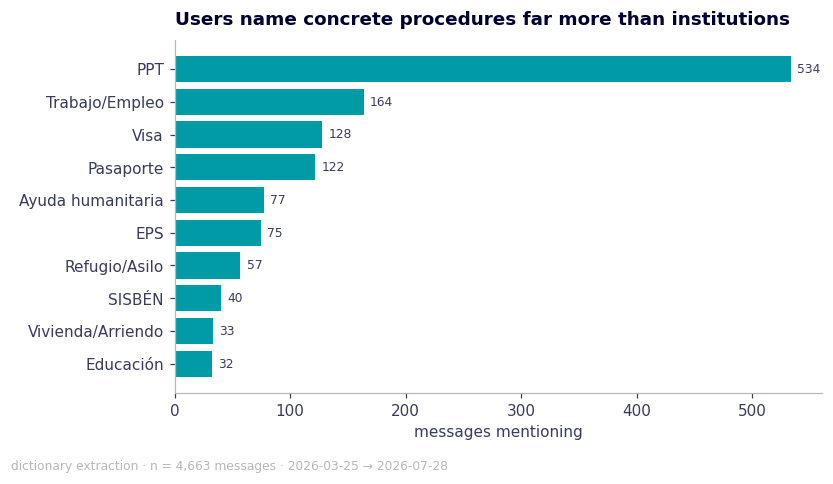

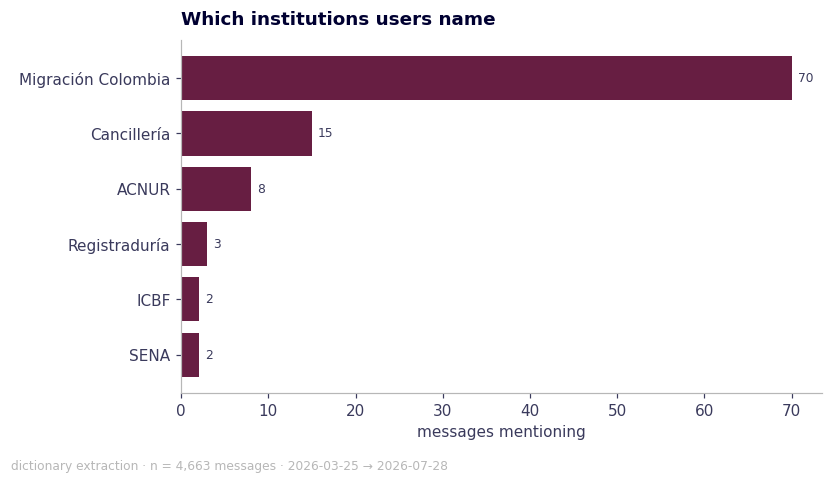

In [5]:
by_kind = taxonomy.entity_counts_by_kind(SD.messages["message"])
n_msgs = len(SD.messages)

# Figure 6a — the concrete procedures & documents users name (teal)
s = by_kind["procedure"].head(10)
fig, ax = plt.subplots(figsize=(7.6, 4.2))
ax.barh(s.index[::-1], s.values[::-1], color=theme.PRIMARY)
for y, v in enumerate(s.values[::-1]):
    ax.text(v + max(s.values) * 0.01, y, str(int(v)), va="center", fontsize=8, color=theme.INK2)
ax.set_title("Users name concrete procedures far more than institutions")
ax.set_xlabel("messages mentioning")
fig.text(0.01, -0.03, f"dictionary extraction · n = {n_msgs:,} messages · {WINDOW}", fontsize=8, color=theme.MUTED)
plt.tight_layout(); plt.show()

# Figure 6b — the institutions users name, on their own axis (wine)
s = by_kind["institution"].head(10)
fig, ax = plt.subplots(figsize=(7.6, 4.2))
ax.barh(s.index[::-1], s.values[::-1], color=theme.ACCENT)
for y, v in enumerate(s.values[::-1]):
    ax.text(v + max(s.values) * 0.01, y, str(int(v)), va="center", fontsize=8, color=theme.INK2)
ax.set_title("Which institutions users name")
ax.set_xlabel("messages mentioning")
fig.text(0.01, -0.03, f"dictionary extraction · n = {n_msgs:,} messages · {WINDOW}", fontsize=8, color=theme.MUTED)
plt.tight_layout(); plt.show()


## 2 · Demand over time  (record-arrival grain — see note above)

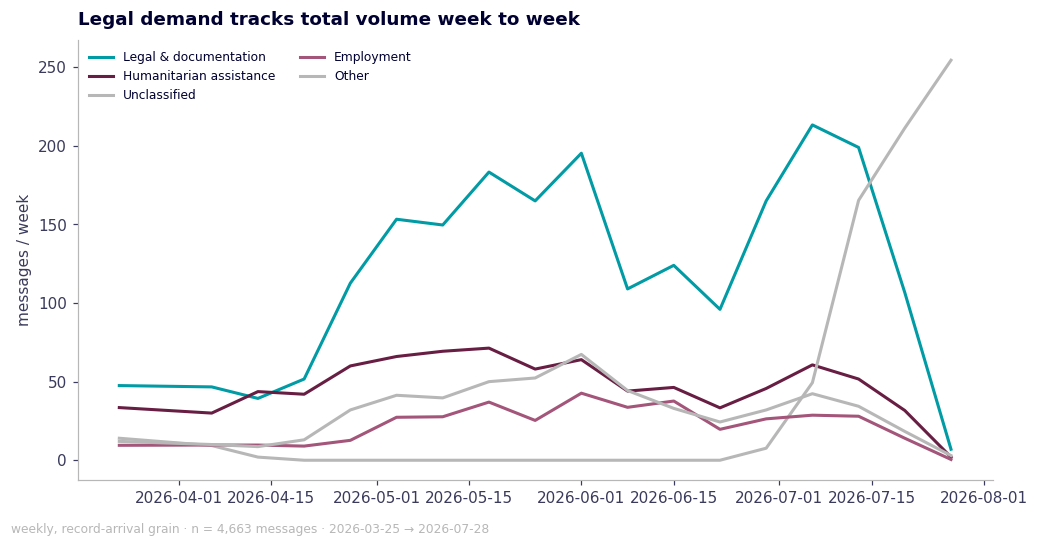

In [6]:
wk = metrics.weekly_category_counts(SD.messages, top_n=4)
fig, ax = plt.subplots(figsize=(9.5, 4.8))
for cat in wk.columns:
    color = CAT_COLOR.get(cat, theme.MUTED)
    x = wk.index; y = wk[cat].values
    ax.plot(x, pd.Series(y, index=x).rolling(3, center=True, min_periods=1).mean(),
            color=color, lw=2, label=CAT_EN.get(cat, cat))        # smoothed spline
ax.set_ylabel("messages / week"); ax.set_xlabel("")
ax.set_title("Legal demand tracks total volume week to week")
ax.legend(fontsize=8, frameon=False, ncol=2)
fig.text(0.01, -0.02, f"weekly, record-arrival grain · n = {len(SD.messages):,} messages · {WINDOW}", fontsize=8, color=theme.MUTED)
plt.tight_layout(); plt.show()


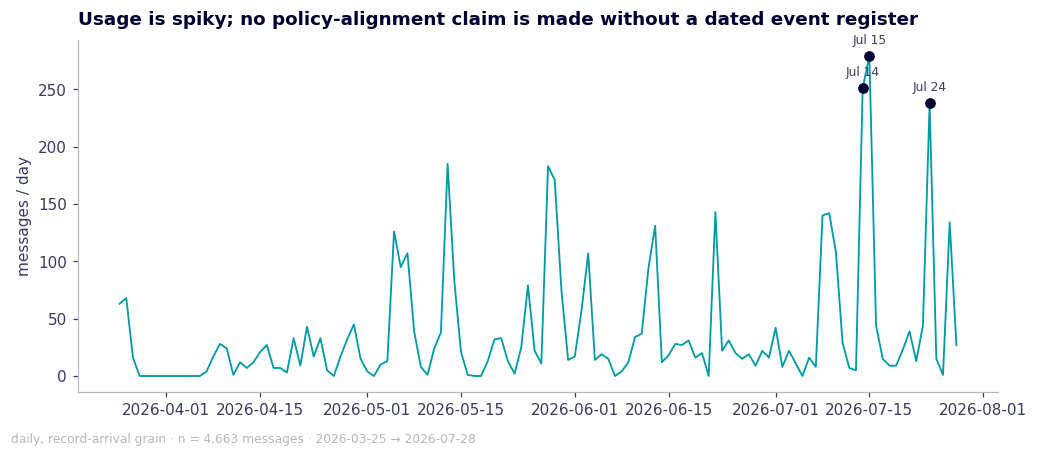

In [7]:
daily = SD.messages.dropna(subset=["ts"]).set_index("ts").resample("D").size()
fig, ax = plt.subplots(figsize=(9.5, 4.0))
ax.plot(daily.index, daily.values, color=theme.PRIMARY, lw=1.2)
top_days = daily.nlargest(3)
for d, v in top_days.items():
    ax.annotate(d.strftime("%b %d"), (d, v), textcoords="offset points",
                xytext=(0, 8), ha="center", fontsize=8, color=theme.INK2)
    ax.scatter([d], [v], color=theme.MADERA, zorder=5)
ax.set_ylabel("messages / day"); ax.set_title("Usage is spiky; no policy-alignment claim is made without a dated event register")
fig.text(0.01, -0.02, f"daily, record-arrival grain · n = {len(SD.messages):,} messages · {WINDOW}", fontsize=8, color=theme.MUTED)
plt.tight_layout(); plt.show()


## 3 · Cross-cuts that earned their place

A cross-cut is shown **only if** its association is both statistically significant *and* carries a non-trivial effect size (Cramér's V ≥ 0.1) on a table where the chi-square approximation is valid (min expected cell ≥ 5). Otherwise it is reported directionally in one line and the figure is dropped — detectable-but-trivial is not a finding.

In [8]:
def show_or_state(a, b, title, xlabel, ylabel, render, varies=None, uniform=None):
    """Always render the cross-cut; the association test decides what we claim.

    V >= 0.1 on adequately-sized cells means the difference is real and the
    figure gets the `varies` headline. Below that the comparison is still drawn
    -- "these groups look alike" is itself an actionable finding for targeting
    -- but it gets the `uniform` headline and a not-significant footnote, so the
    chart never asserts more than the statistics support.
    """
    res = stats.assoc_test(a, b)
    tag = f"V={res['cramers_v']:.2f}, p={res['p']:.3f}, {res['test']}, n={res['n']}"
    res["headline"] = (varies if res["meaningful"] else uniform) or title
    res["note"] = "" if res["meaningful"] else " · differences within noise (V < 0.1)"
    render(res, tag)
    return res


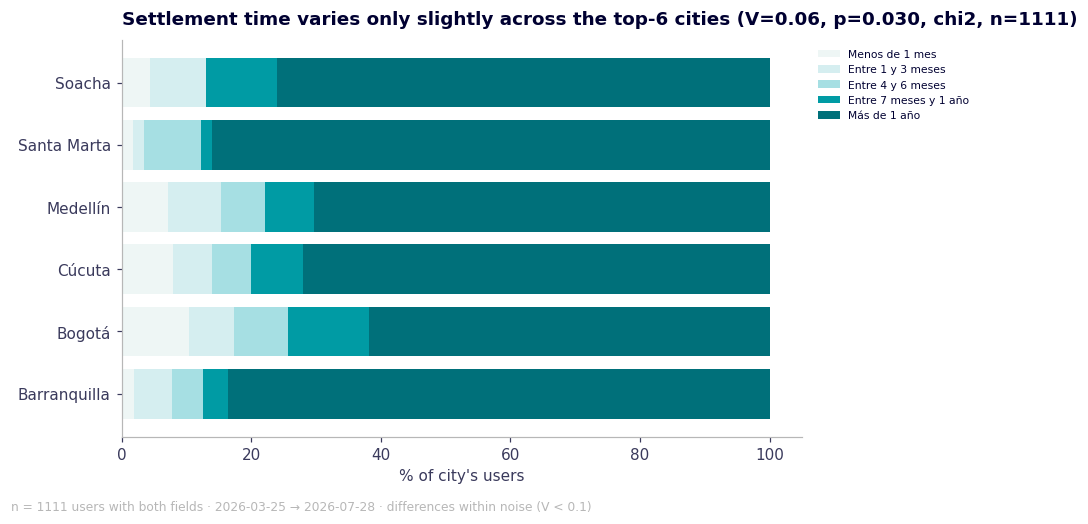

In [9]:
# Settlement duration x city — restricted to the well-populated cities so the
# chi-square table is valid (the full 13-city table is >60% sparse cells, which
# inflates V into a spurious 0.25; on adequately-sized cells the effect is trivial).
resp = SD.responses.dropna(subset=["city_duration_canon", "city_canon"])
resp = resp[resp["city_canon"] != "Otra"]
_top_dur_cities = list(resp["city_canon"].value_counts().head(6).index)
resp = resp[resp["city_canon"].isin(_top_dur_cities)]
def _render_dur_city(res, tag):
    ct = pd.crosstab(resp["city_canon"], resp["city_duration_canon"],
                     normalize="index").reindex(columns=canon.CITY_DURATION_ORDER)
    fig, ax = plt.subplots(figsize=(9, 4.6))
    left = np.zeros(len(ct))
    for i, dur in enumerate(canon.CITY_DURATION_ORDER):
        if dur not in ct.columns: continue
        vals = ct[dur].fillna(0).values * 100
        ax.barh(ct.index, vals, left=left, color=theme.seq_colors(len(canon.CITY_DURATION_ORDER))[i], label=dur)
        left += vals
    ax.set_title(f"{res['headline']} ({tag})")
    ax.set_xlabel("% of city's users"); ax.legend(fontsize=7, frameon=False, bbox_to_anchor=(1.01,1), loc="upper left")
    fig.text(0.01, -0.02, f"n = {res['n']} users with both fields · {WINDOW}{res['note']}", fontsize=8, color=theme.MUTED)
    plt.tight_layout(); plt.show()
_ = show_or_state(resp["city_canon"], resp["city_duration_canon"],
              "duration × city (top-6 cities)", "city", "settlement time", _render_dur_city,
              varies="Settlement time differs by city",
              uniform="Settlement time varies only slightly across the top-6 cities")


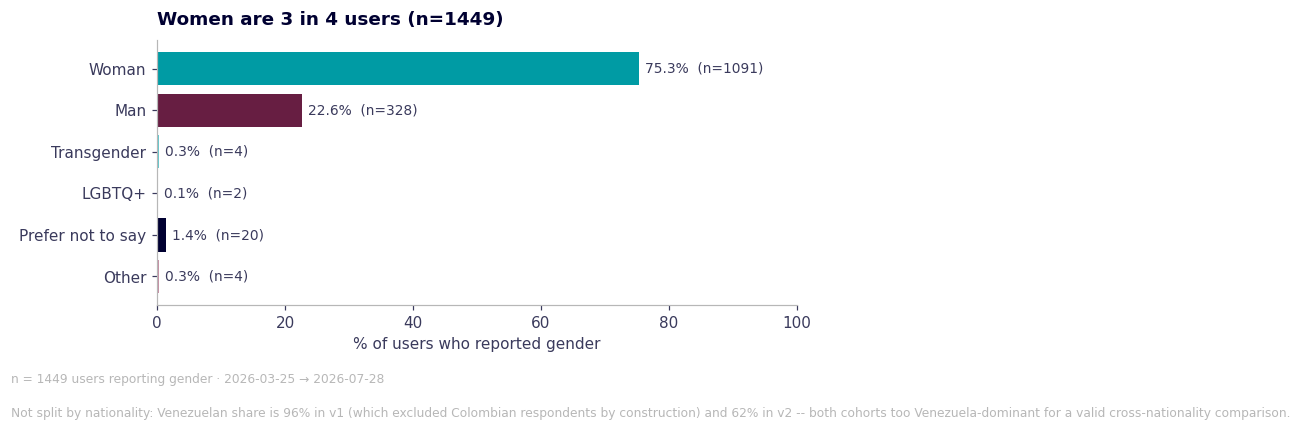

In [10]:
# Gender split — reported for the sample as a whole, NOT crossed with nationality.
# 94% of users who gave a nationality are Venezuelan (the next-largest group is
# Colombia, n=26), so every nationality cell but one is too thin for a valid
# chi-square: min expected count is well under 1. A "Peru" bar would be six people.
g = SD.responses["gender_clean"].dropna().map(canon.gender_display)
# Same closed EN set the gold layer exports (canon.gender_display): the self-described
# identities fold into Transgender / LGBTQ+ instead of one unnamed "other" slice.
_order = ["Woman", "Man", "Transgender", "LGBTQ+", "Prefer not to say", "Other"]
gc = g[g != ""].value_counts().reindex(_order).dropna()
share = gc / gc.sum() * 100

# nationality_canon is SPLIT policy (src/sami/cohort.py) -- v1 excluded Colombian
# respondents by construction, so a pooled Venezuelan share would blend an
# artificially-constrained v1 population with the true v2 one. Report per cohort.
_resp_cohort = SD.responses.assign(instrument_version=cohort.instrument_version(SD.responses).values)
_ven_v1 = (_resp_cohort.loc[_resp_cohort["instrument_version"] == "v1", "nationality_canon"] == "Venezuela").mean() * 100
_ven_v2 = (_resp_cohort.loc[_resp_cohort["instrument_version"] == "v2", "nationality_canon"] == "Venezuela").mean() * 100

fig, ax = plt.subplots(figsize=(7.5, 3.4))
labels = list(gc.index)
ax.barh(labels[::-1], share.values[::-1], color=theme.cat_colors(len(gc))[::-1])
for y, (pct, n) in enumerate(zip(share.values[::-1], gc.values[::-1])):
    ax.text(pct + 1, y, f"{pct:.1f}%  (n={int(n)})", va="center", fontsize=9, color=theme.INK2)
ax.set_xlim(0, 100); ax.set_xlabel("% of users who reported gender")
ax.set_title(f"Women are 3 in 4 users (n={int(gc.sum())})")
fig.text(0.01, -0.04, f"n = {int(gc.sum())} users reporting gender · {WINDOW}", fontsize=8, color=theme.MUTED)
fig.text(0.01, -0.13, f"Not split by nationality: Venezuelan share is {_ven_v1:.0f}% in v1 (which excluded "
                      f"Colombian respondents by construction) and {_ven_v2:.0f}% in v2 -- both cohorts too "
                      f"Venezuela-dominant for a valid cross-nationality comparison.", fontsize=8, color=theme.MUTED)
plt.tight_layout(); plt.show()


> The **age × destination** cut is intentionally omitted: cells are n ≤ 6, below any reliable test threshold (methodology doc 02 §5). Reporting it would invite over-reading of noise.

## 4 · The funnel  (every stage-n traces to the reconciliation table)

Engagement is placed on a single nested axis — message volume — so each stage is a genuine subset of the one before it. The final *surveyed* stage is the MEAL cohort, a separate and smaller feedback population.

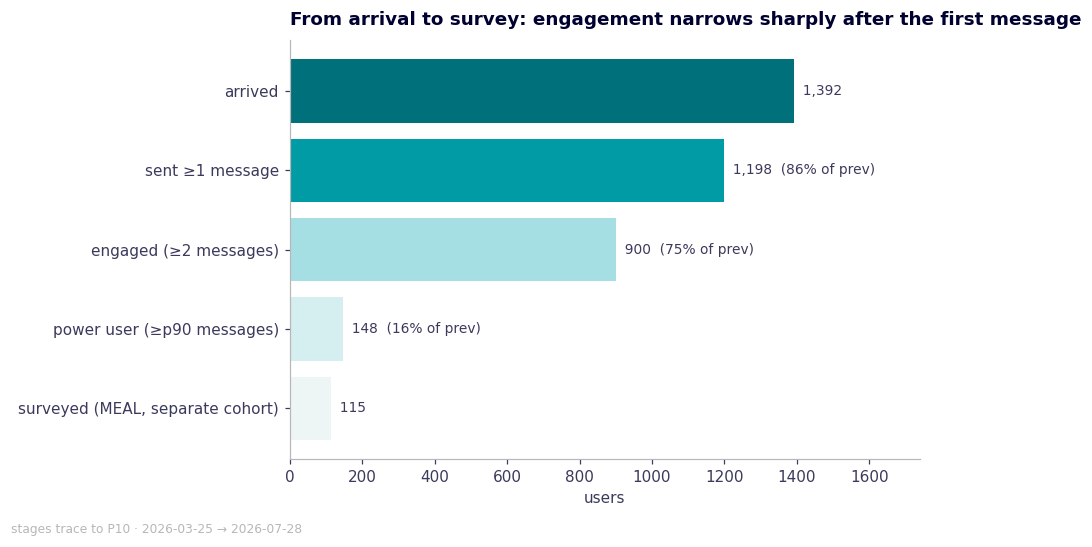

In [11]:
f = metrics.funnel_stages(SD.responses, SD.messages, SD.meal)
fig, ax = plt.subplots(figsize=(8.5, 4.8))
colors = theme.seq_colors(len(f))[::-1]
ax.barh(range(len(f))[::-1], f["n"].values, color=colors)
for i, (_, r) in enumerate(f.iterrows()):
    conv = "" if pd.isna(r["conversion_from_prev"]) else f"  ({r['conversion_from_prev']*100:.0f}% of prev)"
    ax.text(r["n"], len(f)-1-i, f"  {int(r['n']):,}{conv}", va="center", fontsize=9, color=theme.INK2)
ax.set_yticks(range(len(f))[::-1]); ax.set_yticklabels(f["stage"])
ax.set_xlim(0, f["n"].max() * 1.25)
ax.set_title("From arrival to survey: engagement narrows sharply after the first message")
ax.set_xlabel("users")
assert int(f['n'].iloc[0]) == int(SD.reconciliation.set_index('metric').loc['users','value']), "funnel top must equal reconciliation users"
fig.text(0.01, -0.02, f"stages trace to P10 · {WINDOW}", fontsize=8, color=theme.MUTED)
plt.tight_layout(); plt.show()


## 5 · Satisfaction pulse  (MEAL join ≈ 115 users — small-n; warnings shown)

115 of 1,392 users answered the MEAL survey (8.3%). Everything below is a pulse, not a verdict: reach is not satisfaction, and weekly slices are too thin to trend. Ratings are read on a 1–5 ordinal scale.

**Join caveat.** `fact_meal` and the user tables pseudonymize their id columns independently, so the survey pool is not guaranteed to be a subset of the user pool. The cell below joins MEAL respondents to their registration record to recover `instrument_version`; a handful of respondents have no match and are dropped by that join — the exact count is printed with the chart.

**Frozen series.** *“¿Recomendarías este servicio a otras personas migrantes?”* (Q13) was removed when the survey was rewritten. These responses are the complete and final record; the count will not grow, so this must not be read as a trend.

MEAL respondents with no matching user record (join drops them): 3
v1-cohort respondents with a would_recommend answer: 89


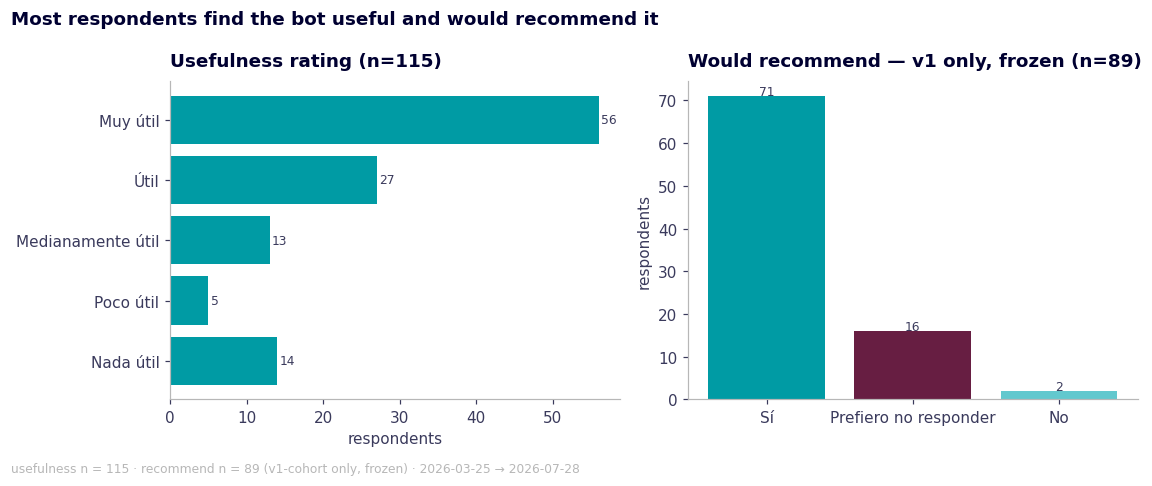

In [12]:
meal = SD.meal
n_meal = meal["user_id"].nunique()
RATING_NUM = {  # ordinal 1-5, keyed to the observed MEAL vocabulary
    "Muy útil": 5, "Útil": 4, "Medianamente útil": 3, "Poco útil": 2, "Nada útil": 1,
}
RATING_ORDER = ["Muy útil", "Útil", "Medianamente útil", "Poco útil", "Nada útil"]
meal = meal.assign(rating_num=meal["usefulness_rating"].map(RATING_NUM))

# would_recommend (Q13) is V1_ONLY (src/sami/cohort.py POLICY) — pool it across
# cohorts and the frozen v1 total silently blends into a v2 population that was
# never asked the question. Recover instrument_version via the earliest record
# per user, the same rule build_agg_funnel uses for its user-level cohort.
resp_cohort = SD.responses.assign(instrument_version=cohort.instrument_version(SD.responses).values)
user_cohort = resp_cohort.groupby("user_id")["instrument_version"].first()
meal = meal.assign(instrument_version=meal["user_id"].map(user_cohort))
n_unmatched = meal["instrument_version"].isna().sum()
meal_v1 = meal[meal["instrument_version"] == "v1"]
n_v1 = meal_v1["would_recommend"].notna().sum()
print(f"MEAL respondents with no matching user record (join drops them): {n_unmatched}")
print(f"v1-cohort respondents with a would_recommend answer: {n_v1}")

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
uc = meal["usefulness_rating"].value_counts().reindex(RATING_ORDER).fillna(0)
axes[0].barh(uc.index[::-1], uc.values[::-1], color=theme.PRIMARY)
for y, v in enumerate(uc.values[::-1]):
    axes[0].text(v + 0.3, y, str(int(v)), va="center", fontsize=8, color=theme.INK2)
axes[0].set_title(f"Usefulness rating (n={n_meal})"); axes[0].set_xlabel("respondents")

rc = meal_v1["would_recommend"].value_counts()
axes[1].bar(rc.index, rc.values, color=theme.cat_colors(len(rc)))
for x, v in enumerate(rc.values):
    axes[1].text(x, v + 0.3, str(int(v)), ha="center", fontsize=8, color=theme.INK2)
axes[1].set_title(f"Would recommend — v1 only, frozen (n={n_v1})"); axes[1].set_ylabel("respondents")
fig.suptitle("Most respondents find the bot useful and would recommend it", x=0.01, ha="left", fontsize=12, weight="semibold")
warn = "" if n_meal >= 20 else "  ⚠ small n"
fig.text(0.01, -0.02, f"usefulness n = {n_meal}{warn} · recommend n = {n_v1} (v1-cohort only, frozen) · {WINDOW}", fontsize=8, color=theme.MUTED)
plt.tight_layout(); plt.show()

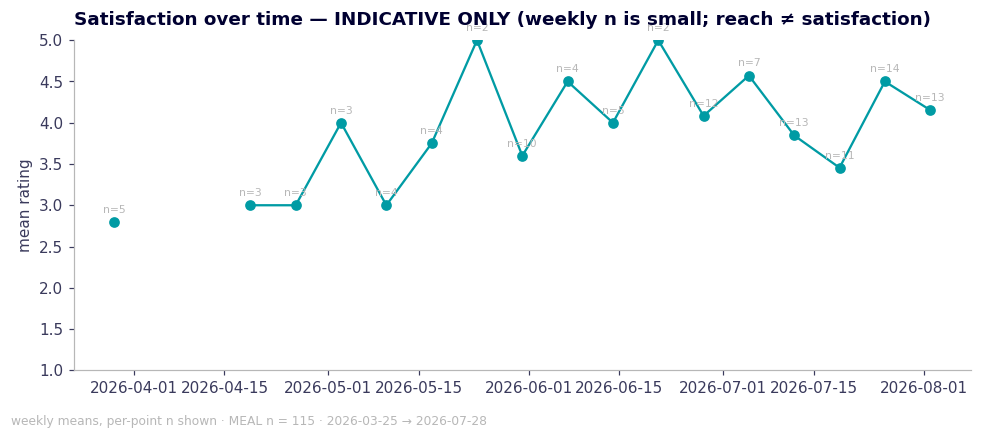

In [13]:
mt = meal.dropna(subset=["ts", "rating_num"]).set_index("ts").resample("W")["rating_num"].agg(["mean","count"])
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(mt.index, mt["mean"], color=theme.PRIMARY, marker="o", lw=1.5)
for x, (m, c) in mt.iterrows():
    if c < 20: ax.annotate(f"n={int(c)}", (x, m), fontsize=7, color=theme.MUTED, xytext=(0,6), textcoords="offset points", ha="center")
ax.set_ylim(1, 5); ax.set_title("Satisfaction over time — INDICATIVE ONLY (weekly n is small; reach ≠ satisfaction)")
ax.set_ylabel("mean rating")
fig.text(0.01, -0.03, f"weekly means, per-point n shown · MEAL n = {n_meal} · {WINDOW}", fontsize=8, color=theme.MUTED)
plt.tight_layout(); plt.show()


### Why the information missed

v2 added *“¿Por qué la información entregada no fue útil?”*, intended only for respondents who rated the service poorly. In production the skip logic misfired and the question reached satisfied respondents too, most of whom answered with a bare negation (“No”, “Nob”…). `fact_meal.reason_is_valid` encodes the intended condition (a poor rating **and** a non-null answer), so only genuinely diagnostic reasons are read below. The valid sample is small — themes only, no percentages.

In [14]:
from sami import export as sami_export

# The v2 skip logic misfired — the question was put to satisfied respondents
# too, who answered with negations. reason_is_valid carries the intended
# condition, so only genuine dissatisfaction reasons are read here. Reuse the
# same rating set the gold fact_meal export uses, rather than re-deriving it.
reason_valid = (meal["usefulness_rating"].isin(sami_export.REASON_VALID_RATINGS)
                & meal["no_usefulness_reason"].notna())
reasons = meal[reason_valid]
n_answered = meal["no_usefulness_reason"].notna().sum()
n_misfired = n_answered - len(reasons)
print(f"{n_answered} respondents answered the question; {n_misfired} of those had rated "
      f"the service Útil/Muy útil — the misfire noise; {len(reasons)} are genuine "
      "dissatisfaction reasons (fact_meal user grain).")
print()
print(reasons["usefulness_rating"].value_counts().to_string())
print()
for rating, text in reasons[["usefulness_rating", "no_usefulness_reason"]].itertuples(index=False):
    print(f"  [{rating}] {text}")

96 respondents answered the question; 65 of those had rated the service Útil/Muy útil — the misfire noise; 31 are genuine dissatisfaction reasons (fact_meal user grain).

usefulness_rating
Nada útil            14
Medianamente útil    13
Poco útil             4

  [Nada útil] Ayuda, no se cómo activar mi línea nueva Tigo y mi internet
  [Medianamente útil] No
  [Nada útil] No recibí información
  [Nada útil] Ayudas en Bucaramanga
  [Medianamente útil] Me necesito hablo con persona ! Esto es urgencia !!!!
  [Nada útil] Que respondan todas las dudas
  [Medianamente útil] Actualizar la dirección de Migración Colombia en Cúcuta
  [Medianamente útil] No
  [Poco útil] Llegue al punto a la una de la tarde y estaba cerrado el punto de atencion en la terminal del norte. Favor no cerrar los puntos
  [Nada útil] necesito saber la dirección de un refugio en cali
  [Nada útil] No
  [Poco útil] No
  [Nada útil] No
  [Nada útil] Como sacar un petróleo tutor
  [Medianamente útil] Mo
  [Medianamente úti

## 6 · Priority matrix — which needs are big *and* badly served

The closing figure of the quantitative arc. It puts demand volume on one axis and an
**unmet-need score** on the other, so the question stops being “what do people ask about?”
and becomes “where is the gap between how much we are asked and how well we answer?”.

The unmet-need score is the mean of three z-scored signals per category: the share of
repeat-askers (a proxy for *not resolved first time*), the share of negatively-toned
messages, and the mean MEAL rating **inverted** so that worse ratings raise the score.

> **Two limits, both carried into the figure itself.** The MEAL join is now 115 users, up
> from the 69 the `min_meal_n=20` fallback guard was tuned against — the guard is left as-is
> (Step 5 below reports honestly which categories still fall back to the overall mean
> rather than moving the goalposts). And the sentiment axis inherits Notebook 3's validation
> result — if Cohen's κ is below 0.7 the axis is **directional**, and the figure says so
> instead of implying a measured rate.

In [15]:
from sami import nlp, validation

# Same compute path as NB3 — sentiment is defined once, in sami.nlp.
sent = nlp.sentiment_messages(SD.messages)

# 'unclassified' is a data-quality bucket, not a need MMC can act on: it has no owner,
# no content roadmap and no referral. Including it would put a labelling artifact in a
# prioritisation figure, so it is excluded here (it stays visible in §1's demand mix).
msgs_pm = SD.messages[SD.messages["dominant_category"] != "unclassified"]
neg_by_cat = metrics.negative_by_category(msgs_pm, sent)

# Inherit NB3's validation verdict rather than restating it by hand.
_analyst = pd.read_csv("../validation/tone_labels_analyst.csv", encoding="utf-8")
_rep = validation.validation_report(_analyst["label_analyst"],
                                    sent.loc[_analyst["message_id"], "label"])
TONE_GATE = _rep["gate_passed"]
print(f"tone validation carried from NB3: κ = {_rep['kappa']:.3f} → "
      f"{'rates quotable' if TONE_GATE else 'DIRECTIONAL axis (levels not quotable)'}")

# MEAL needs the user's dominant category to contribute a per-category rating.
meal_cat = (meal.assign(rating_num=meal["usefulness_rating"].map(RATING_NUM))
                .merge(SD.responses[["user_id", "dominant_category"]].drop_duplicates("user_id"),
                       on="user_id", how="left"))
pm = metrics.priority_matrix_frame(msgs_pm, meal_cat, neg_by_category=neg_by_cat)
pm.assign(category=[CAT_EN.get(i, i) for i in pm.index])[
    ["category", "messages", "users", "pct_repeat", "pct_negative", "mean_rating",
     "meal_n", "rating_is_fallback", "unmet_need"]].round(3)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tone validation carried from NB3: κ = -0.075 → DIRECTIONAL axis (levels not quotable)


,category,messages,users,pct_repeat,pct_negative,mean_rating,meal_n,rating_is_fallback,unmet_need
dominant_category,,,,,,,,,
legal_documentation,Legal & documentation,2170,575,0.127,0.176,3.761,46,False,0.612
humanitarian_assistance,Humanitarian assistance,848,217,0.146,0.154,4.292,24,False,-0.601
employment,Employment,400,128,0.079,0.120,3.922,4,True,-0.425
services,Services,331,108,0.106,0.139,3.922,5,True,-0.130
organization_search,Finding organizations,154,26,0.174,0.136,3.922,3,True,0.278
journey_information,Journey information,45,20,0.000,0.222,3.922,2,True,-0.227
protection,Protection,30,17,0.067,0.267,3.922,1,True,0.492


In [16]:
from sami import qa

# min_meal_n=20 was tuned when MEAL had 69 responses across 8 categories; it now
# has 115. Report honestly which categories still fall back to the overall mean
# rating instead of a per-category one -- the threshold itself is NOT changed here.
fallback_tbl = pm.assign(category=[CAT_EN.get(i, i) for i in pm.index])[
    ["category", "meal_n", "rating_is_fallback"]]
print(fallback_tbl.to_string(index=False))
fallback_cats = fallback_tbl.loc[fallback_tbl["rating_is_fallback"], "category"].tolist()
print()
print(f"{len(fallback_cats)} of {len(fallback_tbl)} categories still fall back: {', '.join(fallback_cats)}")

# Coverage note: the matrix drops 'unclassified' messages. Quantify the share and
# name the actual driver -- a doubled null-summary rate, not the new prose format.
unclass_user_share = (SD.responses["dominant_category"] == "unclassified").mean()
null_share = SD.responses["Chat_summary"].isna().mean()
prose_share = qa._count_prose_share(SD.responses)
print()
print(f"Unclassified share: {unclass_user_share:.1%} of users/responses — driven mostly by "
      f"missing summaries ({null_share:.1%} of Chat_summary is null) rather than the new "
      f"prose format ({prose_share:.1%} of non-null summaries are unparseable prose).")

               category  meal_n  rating_is_fallback
  Legal & documentation      46               False
Humanitarian assistance      24               False
             Employment       4                True
               Services       5                True
  Finding organizations       3                True
    Journey information       2                True
             Protection       1                True

5 of 7 categories still fall back: Employment, Services, Finding organizations, Journey information, Protection

Unclassified share: 22.5% of users/responses — driven mostly by missing summaries (20.9% of Chat_summary is null) rather than the new prose format (1.6% of non-null summaries are unparseable prose).


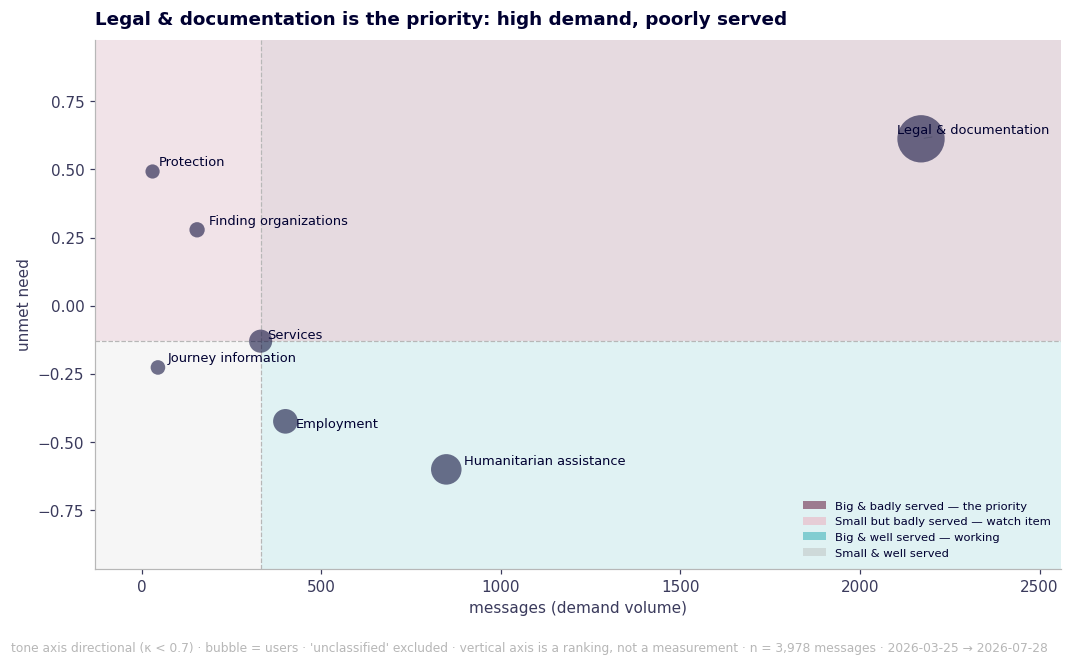

In [17]:
from adjustText import adjust_text
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(9.8, 5.8))
x, y = pm["messages"].values, pm["unmet_need"].values
xm, ym = np.median(x), np.median(y)
ax.set_xlim(-max(x) * 0.06, max(x) * 1.18)
pad = (y.max() - y.min()) * 0.30
ax.set_ylim(y.min() - pad, y.max() + pad)
x0, x1 = ax.get_xlim(); y0, y1 = ax.get_ylim()

# One distinct tint per quadrant so the legend swatches are all tellable apart;
# the priority quadrant (big + badly served) is the loudest. Names live in the
# legend, not as labels crowding the plot.
QUAD = [
    (xm, x1, ym, y1, theme.ACCENT,       0.16, "Big & badly served — the priority"),
    (x0, xm, ym, y1, theme.MADERA_MID,   0.55, "Small but badly served — watch item"),
    (xm, x1, y0, ym, theme.PRIMARY,      0.12, "Big & well served — working"),
    (x0, xm, y0, ym, theme.MUTED,        0.12, "Small & well served"),
]
for xa, xb, ya, yb, col, al, _ in QUAD:
    ax.add_patch(plt.Rectangle((xa, ya), xb - xa, yb - ya, color=col, alpha=al,
                               linewidth=0, zorder=0))
ax.axvline(xm, color=theme.MUTED, lw=0.8, ls="--", zorder=1)
ax.axhline(ym, color=theme.MUTED, lw=0.8, ls="--", zorder=1)

sizes = 60 + (pm["users"].values / pm["users"].max()) * 900
ax.scatter(x, y, s=sizes, color=theme.INK, alpha=0.55, linewidths=0, zorder=3)
texts = [ax.text(xi, yi, CAT_EN.get(cat, cat), fontsize=8.5, color=theme.INK)
         for cat, xi, yi in zip(pm.index, x, y)]
adjust_text(texts, ax=ax, only_move={"text": "xy"},
            arrowprops=dict(arrowstyle="-", color=theme.MUTED, lw=0.6))

ax.set_xlabel("messages (demand volume)")
ax.set_ylabel("unmet need")
for sp in ("top", "right"):
    ax.spines[sp].set_visible(False)
ax.legend(handles=[Patch(facecolor=c, alpha=min(1.0, a * 3.5), label=lbl) for *_, c, a, lbl in QUAD],
          loc="lower right", fontsize=7.5, frameon=False)

big_bad = [c for c in pm.index if pm.loc[c, "messages"] > xm and pm.loc[c, "unmet_need"] > ym]
ax.set_title(f"{CAT_EN.get(big_bad[0], big_bad[0])} is the priority: high demand, poorly served"
             if len(big_bad) == 1 else "Priority needs: high demand, poorly served")
gate_note = "" if TONE_GATE else "tone axis directional (κ < 0.7) · "
fig.text(0.01, -0.03,
         f"{gate_note}bubble = users · 'unclassified' excluded · vertical axis is a ranking, not a "
         f"measurement · n = {len(msgs_pm):,} messages · {WINDOW}",
         fontsize=8, color=theme.MUTED)
plt.tight_layout(); plt.show()


**So what.** **Legal & documentation is the only need that is both high-volume and poorly
served** — the priority for content depth and case-tracking. **Humanitarian assistance**
is the second-largest category but has the *lowest* unmet-need score: high demand, already
working — don't take effort from it. **Protection** is thin (30 messages, 17 users) but
carries the highest unmet-need score: a **watch item with an escalation path**, not a
content workstream.

Read the vertical axis as a **ranking, not a measurement** — it blends three z-scores, one
of them a tone signal that failed its validation bar in Notebook 3.


**Fallback-rating note.** 5 of the 7 categories in the matrix still fall back to the overall mean rating rather than an unstable per-category one — `employment`, `services`, `organization_search`, `journey_information`, `protection` all sit under the `min_meal_n=20` guard even at 115 MEAL responses (only `legal_documentation` and `humanitarian_assistance` clear it). The threshold is unchanged; this is reported so the fallback categories' unmet-need score is read as *demand-and-sentiment-driven*, not rating-driven.

**Coverage note.** The matrix excludes messages whose `dominant_category` is `unclassified` — 22.5% of users/responses today. The driver is **missing summaries**: `Chat_summary` is null for 20.9% of responses (roughly double the pre-migration rate), against only 1.6% in the new v2 prose format the taxonomy cannot map. The new platform's summariser is running on far fewer rows; that is the gap, not the prose rewrite.

## What we now know

- **Demand is overwhelmingly documentation.** Legal & documentation is **46.5 %** of all
  messages — more than double the next category (humanitarian assistance, ~18 %).
- **The demand mix is geographically stable.** Across the top-5 cities plus *Other*, the
  category shares barely move — the same documentation-first pattern repeats everywhere.
- **Users name concrete procedures, not institutions.** *PPT* alone is mentioned in **534**
  messages, dwarfing the most-named institution (*Migración Colombia*, **70**).
- **Engagement narrows sharply after the first message.** Of **1,392** arrivals, **900** send
  ≥2 messages (65 %) and only **148** reach the ≥p90 volume — the drop is steepest into
  power-use, not at the front door.
- **The few who rate us are satisfied — but they are few.** Mean usefulness **3.92 / 5**
  (95 % CI 3.67–4.15) from just **115** respondents (**8.3 %** of users); read as an
  indicative pulse, not a satisfaction verdict.- **Documentation is both the biggest need and the worst served.** On the priority matrix
  it is the only category in the top-right quadrant — high volume and a poor resolution
  profile — making it the clearest investment target. (Ordering is robust; the tone component of the score
  is directional, see §6.)

In [18]:
recon_bottom = SD.reconciliation.copy()
assert recon_top.equals(recon_bottom), "bottom reconciliation must equal the top"
recon_bottom


,metric,value
0,users,1392
1,records,1459
2,messages,4663
3,users_with_text,1198
4,meal_responses,115
5,meal_response_rate_pct,8.3
6,legal_documentation_pct,46.5
7,repeat_askers_pct,10.6
8,negative_tone_pct,pending


In [19]:
from sami import qa
assert qa.pii_scan(SD.responses) == [], "PII in responses"
assert qa.pii_scan(SD.messages) == [], "PII in messages"
assert qa.pii_scan(SD.meal) == [], "PII in meal"
print("PII gate: clean · rendered figures: 10 (cross-cuts dropped; priority matrix now built) ≤ 12 cap")

PII gate: clean · rendered figures: 10 (cross-cuts dropped; priority matrix now built) ≤ 12 cap
